In [55]:
# !wget -c https://github.com/SwinTransformer/storage/releases/download/v1.0.0/swin_tiny_patch4_window7_224.pth

In [10]:
import os
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torchvision.transforms import v2

CONFIG = {
    "image_size": (256, 512),
    "bev_resolution": 0.8,
    "bev_grid_shape": (188, 126),
    "x_bound": (0, 150.4),
    "y_bound": (-50.4, 50.4),
    "z_bound": (-10, 10),
    "d_bound": (4.0, 100.0, 1.0),
    "batch_size": 16,
    "num_workers": 4,
    "lr": 5e-4,
    "epochs": 13,
    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

CAMERA_NAMES = [
    "/camera/inner/frontal/middle",
    "/camera/inner/frontal/far",
    "/side/left/forward",
    "/side/right/forward",
]

INTRINSICS_NAMES = [x + "/intrinsic_params" for x in CAMERA_NAMES]
CAR2CAM_NAMES = [x + "/car_to_cam" for x in CAMERA_NAMES]

In [11]:
class BEVDataset(Dataset):
    def __init__(self, data_dir: Path, mode: str = "train", config=CONFIG):
        """
        data_dir: Путь к папке конкретного сплита (например, .../dataset_train)
        mode: 'train', 'val' (возвращают GT) или 'test' (не возвращает GT)
        """
        self.mode = mode
        self.data_dir = Path(data_dir)
        self.config = config
        
        # Читаем CSV. Ожидается, что info.csv лежит внутри data_dir
        csv_path = self.data_dir / "info.csv"
        if not csv_path.exists():
            raise FileNotFoundError(f"CSV file not found at {csv_path}")
            
        self.info = pd.read_csv(csv_path, index_col=0)
        self.data_root = self.data_dir.parent 
        
        self.transform = v2.Compose([
            v2.ToImage(), 
            v2.ToDtype(torch.float32, scale=True),
            v2.Resize(config["image_size"]),
            v2.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
        ])
        
        self.samples = []
        for idx, row in self.info.iterrows():
            sample = {
                "images": [row[name] for name in CAMERA_NAMES],
                "intrinsics": [row[name] for name in INTRINSICS_NAMES],
                "car2cam": [row[name] for name in CAR2CAM_NAMES],
            }
            if self.mode in ["train", "val"]:
                sample["gt_grid"] = row["gt_occupancy_grid"]
            self.samples.append(sample)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        imgs = []
        intrinsics = []
        car2cams = []
        
        for i in range(4):
            img_path = self.data_root / sample["images"][i]
            pil_img = Image.open(img_path)
            orig_w, orig_h = pil_img.size
            
            img_tensor = self.transform(pil_img)
            imgs.append(img_tensor)
            
            intr_path = self.data_root / sample["intrinsics"][i]
            intr = np.load(intr_path) 
            
            if intr.shape == (3, 4):
                intr = intr[:3, :3]
            
            scale_x = self.config["image_size"][1] / orig_w
            scale_y = self.config["image_size"][0] / orig_h
            intr[0, 0] *= scale_x # fx
            intr[0, 2] *= scale_x # cx
            intr[1, 1] *= scale_y # fy
            intr[1, 2] *= scale_y # cy
            
            intrinsics.append(torch.from_numpy(intr).float())
            
            c2c_path = self.data_root / sample["car2cam"][i]
            c2c = np.load(c2c_path)
            car2cams.append(torch.from_numpy(c2c).float())

        imgs = torch.stack(imgs)
        intrinsics = torch.stack(intrinsics)
        car2cams = torch.stack(car2cams)
        
        cam2cars = torch.inverse(car2cams)

        if self.mode in ["train", "val"]:
            gt_path = self.data_root / sample["gt_grid"]
            gt_grid = np.load(gt_path).astype(np.int64)
            if len(gt_grid.shape) == 2:
                gt_grid = gt_grid[None, ...] # (1, H, W)
            return imgs, intrinsics, cam2cars, torch.from_numpy(gt_grid)
        
        return imgs, intrinsics, cam2cars

In [12]:
from torchvision.models import swin_t, Swin_T_Weights


# class CamEncoder(nn.Module):
#     """
#     Извлекает признаки и предсказывает распределение глубины для изображения.
#     """
#     def __init__(self, D, C, downsample=16):
#         super(CamEncoder, self).__init__()
#         self.D = D # Depth bins
#         self.C = C # Context channels
        
#         # Backbone (ResNet18)
#         # self.backbone = models.resnet50(pretrained=True)
#         self.backbone = models.resnet50(pretrained=True)
#         # state_dict = torch.load("resnet_50_bevformer_epoch_24.pth", map_location="cuda")
#         # self.backbone.load_state_dict(state_dict)
#         self.backbone.fc = nn.Identity()
#         self.backbone.avgpool = nn.Identity()
        
#         # ResNet18 уменьшает размерность в 32 раза.
#         # Для LSS обычно используют stride 16 (downsample)
#         # Удаляем последние слои или используем stride trick, здесь упростим:
#         # Просто используем выход layer4 (512 каналов, stride 32)
#         # Чтобы увеличить разрешение, можно использовать Deconv, но для baseline оставим так.
#         # Выход backbone: (B, 512, H/32, W/32) -> (B, 512, 8, 16) для входа 256x512
        
#         self.depth_net = nn.Conv2d(2048, self.D + self.C, kernel_size=1, padding=0)

#     def get_depth_dist(self, x):
#         return x[:, :self.D].softmax(dim=1)

#     def get_context(self, x):
#         return x[:, self.D:]

#     def forward(self, x):
#         # x: (B*N, 3, H, W)
#         x = self.backbone.conv1(x)
#         x = self.backbone.bn1(x)
#         x = self.backbone.relu(x)
#         x = self.backbone.maxpool(x)

#         x = self.backbone.layer1(x)
#         x = self.backbone.layer2(x)
#         x = self.backbone.layer3(x)
#         x = self.backbone.layer4(x) # (B*N, 512, H/32, W/32)
        
#         x = self.depth_net(x)
        
#         depth = self.get_depth_dist(x)
#         context = self.get_context(x)
        
#         return depth, context


class CamEncoder(nn.Module):
    """
    Извлекает признаки и предсказывает распределение глубины для изображения.
    Backbone: Swin Transformer (swin_t).
    """
    def __init__(self, D, C, downsample=32):
        super(CamEncoder, self).__init__()
        self.D = D
        self.C = C

        weights = Swin_T_Weights.IMAGENET1K_V1
        self.backbone = swin_t(weights=weights)

        in_channels = self.backbone.head.in_features  # для swin_t = 768

        self.depth_net = nn.Conv2d(in_channels, self.D + self.C, kernel_size=1)

    def get_depth_dist(self, x):
        # x: (B, D + C, H, W)
        return x[:, :self.D].softmax(dim=1)

    def get_context(self, x):
        return x[:, self.D:]

    def forward(self, x):
        x = self.backbone.features(x)          # (B, H', W', C)
        x = self.backbone.norm(x)              # (B, H', W', C)

        x = self.backbone.permute(x)           # (B, C, H', W')
        x = self.depth_net(x)                  # (B, D + C, H', W')
        depth = self.get_depth_dist(x)         # (B, D, H', W')
        context = self.get_context(x)          # (B, C, H', W')

        return depth, context

In [13]:
class ViewTransformer(nn.Module):
    """
    Переводит 2D признаки в 3D облако точек и проецирует их в BEV сетку.
    """
    def __init__(self, grid_conf, data_conf):
        super(ViewTransformer, self).__init__()
        self.grid_conf = grid_conf
        self.data_conf = data_conf
        
        dx, bx, nx = self.gen_dx_bx(self.grid_conf['x_bound'], self.grid_conf['y_bound'], self.grid_conf['z_bound'])
        self.dx = nn.Parameter(dx, requires_grad=False)
        self.bx = nn.Parameter(bx, requires_grad=False)
        self.nx = nn.Parameter(nx, requires_grad=False)

        self.D = int((data_conf['d_bound'][1] - data_conf['d_bound'][0]) / data_conf['d_bound'][2])
        self.frustum = self.create_frustum()

    def gen_dx_bx(self, xbound, ybound, zbound):
        dx = torch.Tensor([0.8, 0.8, 20.0]) 
        bx = torch.Tensor([xbound[0] + 0.4, ybound[0] + 0.4, zbound[0]])
        nx = torch.LongTensor([(xbound[1] - xbound[0]) / 0.8, (ybound[1] - ybound[0]) / 0.8, 1])
        return dx, bx, nx

    def create_frustum(self):
        feat_h, feat_w = 8, 16 
        ds = torch.arange(*self.data_conf['d_bound'], dtype=torch.float).view(-1, 1, 1).expand(-1, feat_h, feat_w)
        D, H, W = ds.shape
        xs = torch.linspace(0, self.data_conf['image_size'][1] - 1, W).view(1, 1, W).expand(D, H, W)
        ys = torch.linspace(0, self.data_conf['image_size'][0] - 1, H).view(1, H, 1).expand(D, H, W)
        frustum = torch.stack((xs, ys, ds), -1)
        return nn.Parameter(frustum, requires_grad=False)

    def get_geometry(self, rots, trans, intrinsics):
        B, N, _ = trans.shape
        points = self.frustum.unsqueeze(0).unsqueeze(0).unsqueeze(-1)
        points = torch.cat((points[:, :, :, :, :, :2] * points[:, :, :, :, :, 2:3], points[:, :, :, :, :, 2:3]), 5)
        combined_transform = torch.inverse(intrinsics)
        points = combined_transform.view(B, N, 1, 1, 1, 3, 3).matmul(points).squeeze(-1)
        points = rots.view(B, N, 1, 1, 1, 3, 3).matmul(points.unsqueeze(-1)).squeeze(-1)
        points += trans.view(B, N, 1, 1, 1, 3)
        return points

    def voxel_pooling(self, geom_feats, x):
        """
        Складывает фичи, попавшие в один воксель.
        """
        B, N, D, H, W, _ = geom_feats.shape
        
        geom_feats = geom_feats.reshape(B, -1, 3) 
        feats = x.reshape(B, -1, x.shape[-1])
        # -------------------------
        
        long_coords = ((geom_feats - self.bx.to(geom_feats.device)) / self.dx.to(geom_feats.device)).long()
        
        valid = (long_coords[:, :, 0] >= 0) & (long_coords[:, :, 0] < self.nx[0]) & \
                (long_coords[:, :, 1] >= 0) & (long_coords[:, :, 1] < self.nx[1]) & \
                (long_coords[:, :, 2] >= 0) & (long_coords[:, :, 2] < self.nx[2])
        
        bev_map = torch.zeros((B, self.data_conf['bev_grid_shape'][0], self.data_conf['bev_grid_shape'][1], feats.shape[-1]), device=feats.device)
        
        for b in range(B):
            cur_valid = valid[b]
            cur_coords = long_coords[b][cur_valid]
            cur_feats = feats[b][cur_valid]
            
            if cur_coords.shape[0] == 0:
                continue
            
            bev_map[b].index_put_((cur_coords[:, 0], cur_coords[:, 1]), cur_feats, accumulate=True)

        return bev_map.permute(0, 3, 1, 2).contiguous()

    def forward(self, x, rots, trans, intrinsics):
        B, N, C, D, H, W = x.shape
        x = x.permute(0, 1, 3, 4, 5, 2) # (B, N, D, H, W, C)
        geom = self.get_geometry(rots, trans, intrinsics) 
        bev = self.voxel_pooling(geom, x)
        return bev

class BEVModel(nn.Module):
    def __init__(self, conf):
        super(BEVModel, self).__init__()
        self.conf = conf
        self.C = 64 # Каналы признаков
        self.D = int((conf['d_bound'][1] - conf['d_bound'][0]) / conf['d_bound'][2])
        
        self.cam_encoder = CamEncoder(self.D, self.C, downsample=16)
        self.view_transformer = ViewTransformer(conf, conf)
        
        # Декодер BEV (простой U-Net like или ResNet блоки)
        # Вход: 64 канала. Выход: 1 канал (logits)
        self.bev_decoder = nn.Sequential(
            nn.Conv2d(self.C, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 1, 1) # Итоговый предиктор
        )

    def forward(self, images, intrinsics, cam2cars):
        B, N, C, H, W = images.shape

        images_flat = images.view(B*N, C, H, W)
        depth_dist, context = self.cam_encoder(images_flat)
        
        x = context.unsqueeze(2) * depth_dist.unsqueeze(1)
        
        x = x.view(B, N, self.C, self.D, x.shape[-2], x.shape[-1])
        
        rots = cam2cars[:, :, :3, :3]
        trans = cam2cars[:, :, :3, 3]
        
        bev_feat = self.view_transformer(x, rots, trans, intrinsics)
        
        logits = self.bev_decoder(bev_feat) # (B, 1, 188, 126)
        
        return logits

In [14]:
def calculate_iou(preds, targets, ignore_index=255):
    """
    Считает Macro IoU: (IoU_class_0 + IoU_class_1) / 2.
    Игнорирует пиксели со значением ignore_index (обычно 255).
    """
    preds_sigmoid = torch.sigmoid(preds)
    preds_bin = preds_sigmoid > 0.5
    
    valid_mask = (targets != ignore_index)
    
    tp_1 = (preds_bin & (targets == 1) & valid_mask).sum().float()
    union_1 = ((preds_bin | (targets == 1)) & valid_mask).sum().float()
    
    iou_1 = (tp_1 + 1e-6) / (union_1 + 1e-6)
    tp_0 = ((~preds_bin) & (targets == 0) & valid_mask).sum().float()
    union_0 = (((~preds_bin) | (targets == 0)) & valid_mask).sum().float()
    
    iou_0 = (tp_0 + 1e-6) / (union_0 + 1e-6)
    macro_iou = (iou_1 + iou_0) / 2
    
    return macro_iou.item()


def visualize_batch(images, gt_grid, pred_grid, epoch, batch_idx):
    """
    Рисует первые 4 камеры и сравнение GT vs Pred BEV
    """
    B = images.shape[0]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    cam_names = ["Front", "Far", "Left", "Right"]
    for i in range(4):
        ax = axes.flatten()[i]
        img = images[0, i].permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(cam_names[i])
        ax.axis('off')
        
    # GT BEV
    ax_gt = axes[1, 1]
    gt_vis = gt_grid[0, 0].cpu().numpy()
    vis_map = np.zeros((*gt_vis.shape, 3))
    vis_map[gt_vis == 0] = [1, 0, 0]
    vis_map[gt_vis == 1] = [1, 1, 1]
    vis_map[gt_vis == 255] = [0, 0, 0.5]
    
    ax_gt.imshow(vis_map, origin='lower')
    ax_gt.set_title("Ground Truth")
    
    ax_pred = axes[1, 2]
    pred_prob = torch.sigmoid(pred_grid[0, 0]).detach().cpu().numpy()
    ax_pred.imshow(pred_prob, cmap='magma', origin='lower', vmin=0, vmax=1)
    ax_pred.set_title("Prediction (Prob)")

    plt.tight_layout()
    os.makedirs("viz", exist_ok=True)
    plt.savefig(f"viz/epoch_{epoch}_batch_{batch_idx}.png")
    plt.close()


In [15]:
def main():
    train_dir = Path("aidao2025/autonomy_yandex_dataset_train")
    val_dir   = Path("aidao2025/autonomy_yandex_dataset_val") 

    train_dataset = BEVDataset(train_dir, mode="train", config=CONFIG)
    val_dataset   = BEVDataset(val_dir,   mode="val",   config=CONFIG)

    print(f"Sizes: Train={len(train_dataset)}, Val={len(val_dataset)}")

    train_loader = DataLoader(
        train_dataset, 
        batch_size=CONFIG['batch_size'], 
        shuffle=True,             # Train перемешиваем
        num_workers=CONFIG['num_workers'],
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset, 
        batch_size=CONFIG['batch_size'],
        shuffle=False,
        num_workers=CONFIG['num_workers'],
        pin_memory=True
    )
    
    model = BEVModel(CONFIG).to(CONFIG['device'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['lr'])
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=3e-3, # Пиковый LR
        total_steps=CONFIG['epochs'] * len(train_loader),
        pct_start=0.3, # 30% времени на разгон
        div_factor=10,
        final_div_factor=100
    )
    
    print(f"Starting training on {CONFIG['device']}...")
    
    for epoch in range(CONFIG['epochs']):
        model.train()
        train_loss = 0
        train_iou = 0
        
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")
        for batch_idx, (imgs, intrs, c2c, gt) in enumerate(pbar):
            imgs = imgs.to(CONFIG['device'])
            intrs = intrs.to(CONFIG['device'])
            c2c = c2c.to(CONFIG['device'])
            gt = gt.to(CONFIG['device']) # (B, 1, 188, 126)
            
            optimizer.zero_grad()
            
            preds = model(imgs, intrs, c2c)

            mask = (gt != 255).float()
            loss = criterion(preds, gt.float())
            loss = (loss * mask).sum() / (mask.sum() + 1e-6)
            
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            # Metrics
            iou = calculate_iou(preds, gt)
            
            train_loss += loss.item()
            train_iou += iou
            
            pbar.set_postfix({'loss': loss.item(), 'iou': iou})
            
            if batch_idx % 100 == 0:
                visualize_batch(imgs, gt, preds, epoch, batch_idx)

        print(f"Train Epoch {epoch+1}: Avg Loss: {train_loss/len(train_loader):.4f}, Avg IoU: {train_iou/len(train_loader):.4f}")
        
        # Validation
        model.eval()
        val_loss = 0
        val_iou = 0
        with torch.no_grad():
            for imgs, intrs, c2c, gt in tqdm(val_loader, desc="Validation"):
                imgs = imgs.to(CONFIG['device'])
                intrs = intrs.to(CONFIG['device'])
                c2c = c2c.to(CONFIG['device'])
                gt = gt.to(CONFIG['device'])
                
                preds = model(imgs, intrs, c2c)
                
                mask = (gt != 255).float()
                
                loss = criterion(preds, gt.float())
                loss = (loss * mask).sum() / (mask.sum() + 1e-6)
                
                val_loss += loss.item()
                val_iou += calculate_iou(preds, gt)
                
        print(f"Val Epoch {epoch+1}: Avg Loss: {val_loss/len(val_loader):.4f}, Avg IoU: {val_iou/len(val_loader):.4f}")
        
        torch.save(model.state_dict(), f"lss_models_last_hope/lss_model_epoch_{epoch}.pth")

Sizes: Train=4000, Val=1000
Starting training on cuda...


Epoch 1/13: 100%|██████████| 250/250 [03:27<00:00,  1.20it/s, loss=0.611, iou=0.458]


Train Epoch 1: Avg Loss: 0.6074, Avg IoU: 0.4859


Validation: 100%|██████████| 63/63 [00:28<00:00,  2.18it/s]


Val Epoch 1: Avg Loss: 0.6081, Avg IoU: 0.4685


...

Train Epoch 2: Avg Loss: 0.5933, Avg IoU: 0.5016


Validation: 100%|██████████| 63/63 [00:28<00:00,  2.22it/s]


Val Epoch 2: Avg Loss: 0.6093, Avg IoU: 0.4838


Epoch 3/13:  10%|█         | 25/250 [00:24<03:37,  1.04it/s, loss=0.6, iou=0.497]  


KeyboardInterrupt: 

In [ ]:
main()

# проверка валидации

In [19]:
def calculate_iou_new(preds, targets, ignore_index=255):
    """
    Считает Macro IoU: (IoU_class_0 + IoU_class_1) / 2.
    Игнорирует пиксели со значением ignore_index (обычно 255).
    """
    # 1. Получаем бинарные предсказания (0 или 1)
    preds_sigmoid = torch.sigmoid(preds)
    preds_bin = preds_sigmoid > 0.5  # True, где предсказан класс 1
    
    # 2. Создаем маску валидных пикселей (исключаем 255)
    valid_mask = (targets != ignore_index)
    
    # --- IoU для Класса 1 (Занято / Occupied) ---
    # Intersection: Предсказано 1 И Истина 1 (в валидной зоне)
    tp_1 = (preds_bin & (targets == 1) & valid_mask).sum().float()
    # Union: Предсказано 1 ИЛИ Истина 1 (в валидной зоне)
    union_1 = ((preds_bin | (targets == 1)) & valid_mask).sum().float()
    
    iou_1 = (tp_1 + 1e-6) / (union_1 + 1e-6)
    
    # --- IoU для Класса 0 (Свободно / Free) ---
    # Intersection: Предсказано 0 И Истина 0 (в валидной зоне)
    # ~preds_bin означает "НЕ 1", то есть 0
    tp_0 = ((~preds_bin) & (targets == 0) & valid_mask).sum().float()
    # Union: Предсказано 0 ИЛИ Истина 0 (в валидной зоне)
    union_0 = (((~preds_bin) | (targets == 0)) & valid_mask).sum().float()
    
    iou_0 = (tp_0 + 1e-6) / (union_0 + 1e-6)
    
    # --- Macro Average ---
    macro_iou = (iou_1 + iou_0) / 2
    
    return macro_iou.item()

In [43]:
val_dir   = Path("aidao2025/autonomy_yandex_dataset_val") 

val_dataset   = BEVDataset(val_dir,   mode="val",   config=CONFIG)
val_loader = DataLoader(
    val_dataset, 
    batch_size=CONFIG['batch_size'], # Можно ставить больше, если влезает в память (нет градиентов)
    shuffle=False,            # Val не перемешиваем
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

In [44]:
model = BEVModel(CONFIG).to(CONFIG['device'])
model.load_state_dict(torch.load("lss_models_pretrained_resnet50/lss_model_epoch_5.pth"))

<ipython-input-39-9f522941c304>:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("resnet_50_bevformer_epoch_24.pth", map_location="cuda")
<ipython-i

<All keys matched successfully>

In [45]:
model.eval()
val_loss = 0
val_iou_new = 0
val_iou_old = 0
with torch.no_grad():
    for imgs, intrs, c2c, gt in tqdm(val_loader, desc="Validation"):
        imgs = imgs.to(CONFIG['device'])
        intrs = intrs.to(CONFIG['device'])
        c2c = c2c.to(CONFIG['device'])
        gt = gt.to(CONFIG['device'])

        preds = model(imgs, intrs, c2c)

        mask = (gt != 255).float()
        val_iou_new += calculate_iou_new(preds, gt)
        val_iou_old += calculate_iou_old(preds, gt)
        
print(f"Avg IoU NEW: {val_iou_new/len(val_loader):.4f}")
print(f"Avg IoU OLD: {val_iou_old/len(val_loader):.4f}")

Validation: 100%|██████████| 63/63 [00:28<00:00,  2.19it/s]

Avg IoU NEW: 0.5299
Avg IoU OLD: 0.4652


# отрисовка валидций

In [31]:
test_dir  = Path("aidao2025/autonomy_yandex_dataset_test")


test_dataset  = BEVDataset(test_dir,  mode="test",  config=CONFIG)


test_loader = DataLoader(
    test_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False,            # Test не перемешиваем
    num_workers=CONFIG['num_workers'],
    pin_memory=True
    )

In [32]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path

def save_batch_visualization(images, pred_logits, gt_grid, batch_idx, save_dir, prefix="val"):
    """
    images: (B, 4, 3, H, W) - тензор картинок
    pred_logits: (B, 1, 188, 126) - логиты модели
    gt_grid: (B, 1, 188, 126) или None - истинная карта
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # Берем первый пример из батча
    idx = 0 
    
    # Подготовка картинок камер
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    
    # Денормализация для красоты
    vis_imgs = images[idx].cpu() * std + mean
    vis_imgs = torch.clamp(vis_imgs, 0, 1) # (4, 3, H, W)
    
    # Подготовка карты предсказания
    pred_prob = torch.sigmoid(pred_logits[idx, 0]).detach().cpu().numpy()
    
    # Настройка Plot
    cols = 3
    rows = 2
    fig, axes = plt.subplots(rows, cols, figsize=(16, 9))
    plt.suptitle(f"{prefix} | Batch {batch_idx} | Sample {idx}", fontsize=16)
    
    # 1. Рисуем 4 камеры
    cam_names = ["Front Middle", "Front Far", "Left", "Right"]
    cam_indices = [(0, 0), (0, 1), (1, 0), (1, 1)] # Позиции в subplot для камер (условно)
    
    # Для удобства разместим камеры так:
    # [Front Mid] [Front Far] [PRED MAP]
    # [Left]      [Right]     [GT MAP]
    
    # Камеры
    axes[0, 0].imshow(vis_imgs[0].permute(1, 2, 0))
    axes[0, 0].set_title("Front Middle")
    
    axes[0, 1].imshow(vis_imgs[1].permute(1, 2, 0))
    axes[0, 1].set_title("Front Far")
    
    axes[1, 0].imshow(vis_imgs[2].permute(1, 2, 0))
    axes[1, 0].set_title("Left Side")
    
    axes[1, 1].imshow(vis_imgs[3].permute(1, 2, 0))
    axes[1, 1].set_title("Right Side")
    
    # 2. Рисуем Prediction
    ax_pred = axes[0, 2]
    im = ax_pred.imshow(pred_prob, origin='lower', cmap='magma', vmin=0, vmax=1)
    ax_pred.set_title("Prediction (Prob)")
    plt.colorbar(im, ax=ax_pred, fraction=0.046, pad=0.04)
    
    # 3. Рисуем GT (если есть)
    ax_gt = axes[1, 2]
    if gt_grid is not None:
        gt_vis = gt_grid[idx, 0].cpu().numpy() # (188, 126)
        
        # Красим: 0 (свободно) -> Зеленый/Красный, 1 (занято) -> Белый
        # Но проще отобразить просто маску
        vis_map = np.zeros((*gt_vis.shape, 3))
        vis_map[gt_vis == 0] = [0, 0, 0]       # Free (Black)
        vis_map[gt_vis == 1] = [1, 1, 1]       # Occupied (White)
        vis_map[gt_vis == 255] = [0.5, 0, 0]   # Unknown/Ignore (Dark Red)
        
        ax_gt.imshow(vis_map, origin='lower')
        ax_gt.set_title("Ground Truth")
    else:
        ax_gt.axis('off')
        ax_gt.text(0.5, 0.5, "No GT (Test)", ha='center')

    for ax in axes.flatten():
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(save_dir / f"{prefix}_batch_{batch_idx}.png")
    plt.close()

In [33]:
def run_validation(model, loader, device, output_dir="viz_val"):
    model.eval()
    total_iou = 0
    total_loss = 0
    criterion = torch.nn.BCEWithLogitsLoss(reduction='none')
    
    print(f"Starting validation. Saving images to {output_dir}/ ...")
    
    with torch.no_grad():
        for batch_idx, (imgs, intrs, c2c, gt) in enumerate(loader):
            imgs = imgs.to(device)
            intrs = intrs.to(device)
            c2c = c2c.to(device)
            gt = gt.to(device)
            
            # Инференс
            preds = model(imgs, intrs, c2c)
            
            # Считаем Loss
            mask = (gt != 255).float()
            loss = criterion(preds, gt.float())
            loss = (loss * mask).sum() / (mask.sum() + 1e-6)
            total_loss += loss.item()
            
            # Считаем IoU
            # Сигмоида -> Порог 0.5 -> Сравнение с GT (учитывая маску)
            pred_mask = (torch.sigmoid(preds) > 0.5)
            gt_mask = (gt == 1)
            valid_region = (gt != 255)
            
            intersection = (pred_mask & gt_mask & valid_region).sum().float()
            union = ((pred_mask | gt_mask) & valid_region).sum().float()
            iou = (intersection + 1e-6) / (union + 1e-6)
            total_iou += iou.item()
            
            # Визуализация каждые 10 батчей
            if batch_idx % 10 == 0:
                save_batch_visualization(imgs, preds, gt, batch_idx, output_dir, prefix="val")

    avg_loss = total_loss / len(loader)
    avg_iou = total_iou / len(loader)
    print(f"Validation Complete. Avg Loss: {avg_loss:.4f}, Avg IoU: {avg_iou:.4f}")
    return avg_iou

In [34]:
def run_test_inference(model, loader, device, viz_dir="viz_test", pred_dir="predictions"):
    model.eval()
    
    viz_path = Path(viz_dir)
    pred_path = Path(pred_dir)
    viz_path.mkdir(exist_ok=True)
    pred_path.mkdir(exist_ok=True)
    
    print(f"Starting TEST inference.")
    print(f"Visualizations -> {viz_dir}/")
    print(f"Numpy predictions -> {pred_dir}/")
    
    with torch.no_grad():
        for batch_idx, (imgs, intrs, c2c) in enumerate(tqdm(loader, desc="Test Inference")):
            imgs = imgs.to(device)
            intrs = intrs.to(device)
            c2c = c2c.to(device)
            
            # Инференс
            logits = model(imgs, intrs, c2c)
            probs = torch.sigmoid(logits) # (B, 1, 188, 126)
            
            # Сохранение результатов (numpy)
            # Конвертируем в 0/1 или оставляем вероятности (зависит от условий задачи)
            # Обычно сохраняют бинарную маску uint8
            binary_preds = (probs > 0.5).cpu().numpy().astype(np.uint8)
            
            # Сохраняем каждый семпл из батча
            for i in range(binary_preds.shape[0]):
                # Генерируем уникальное имя (можно брать ID из датасета, если он возвращает ID)
                # Здесь используем индекс
                file_name = f"pred_batch{batch_idx}_sample{i}.npy"
                np.save(pred_path / file_name, binary_preds[i, 0])
            
            # Визуализация каждые 10 батчей
            if batch_idx % 10 == 0:
                save_batch_visualization(imgs, logits, None, batch_idx, viz_path, prefix="test")
                
    print("Test inference finished.")

# подготовка сабмита

<ipython-input-16-f442a6a9db0f>:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(weights_path, map_location=device))


Loading weights from lss_models_find_best/lss_model_epoch_5.pth...
Starting inference on 2000 samples...


  0%|          | 0/2000 [00:00<?, ?it/s]

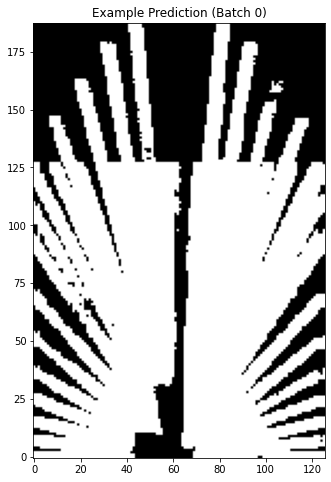

100%|██████████| 2000/2000 [01:09<00:00, 28.61it/s]

Inference completed. Files saved.


In [16]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

def generate_submission(model, weights_path, test_data_dir):
    device = CONFIG['device']
    test_data_dir = Path(test_data_dir)
    test_info = pd.read_csv(test_data_dir / "info.csv") 
    test_dataset = BEVDataset(test_data_dir, mode="test", config=CONFIG)
    
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)
    
    print(f"Loading weights from {weights_path}...")
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    
    print(f"Starting inference on {len(test_dataset)} samples...")
    
    with torch.inference_mode():
        for i, batch in enumerate(tqdm(test_loader)):
            imgs, intrs, c2c = batch
            imgs = imgs.to(device)
            intrs = intrs.to(device)
            c2c = c2c.to(device)
            
            logits = model(imgs, intrs, c2c) # (1, 1, 188, 126)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).long()
            
            if i == 0:
                plt.figure(figsize=(6, 8))
                plt.imshow(preds[0, 0].cpu().numpy(), origin='lower', cmap='gray')
                plt.title("Example Prediction (Batch 0)")
                plt.show()
            
            preds_numpy = preds.cpu().numpy().astype(np.int32)
            rel_path = test_info.iloc[i]["predicted_occupancy_grid"]
            save_path = test_dataset.data_root / rel_path
            
            # Убедимся, что папка существует
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            # Сохраняем .npy
            np.save(save_path, preds_numpy)

    print("Inference completed. Files saved.")

WEIGHTS_FILE = "lss_models_find_best/lss_model_epoch_5.pth"
TEST_DIR = "aidao2025/autonomy_yandex_dataset_test/"
model = BEVModel(CONFIG)
generate_submission(model, WEIGHTS_FILE, TEST_DIR)